Movie Trends Analysis 

In [315]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import ast

In [317]:
df = pd.read_csv("C:\\Users\\ASUS\\Downloads\\movie analysis\\tmdb_5000_movies.csv")

Basic info

In [320]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


Data Cleaning and handlling missing data

In [323]:
df.isnull().sum()

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

In [325]:
df.dropna(subset=['release_date'], inplace=True)

In [327]:
df['budget'] = df['budget'].fillna(0)
df['revenue'] = df['revenue'].fillna(0)
df['overview'] = df['overview'].fillna('Unknown')
df['tagline'] = df['tagline'].fillna('Unknown')
df['homepage'] = df['homepage'].fillna('Unknown')

In [329]:
df.isnull().sum()
df[df.isnull().any(axis=1)]
df.isnull().values.any()  

True

In [331]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.802000e+03,4802.000000,4802.000000,4.802000e+03,4800.000000,4802.000000,4802.000000
mean,2.905109e+07,57098.234902,21.496776,8.227777e+07,106.898125,6.093440,690.361724
std,4.072447e+07,88581.302370,31.818451,1.628697e+08,22.561593,1.191496,1234.674268
min,0.000000e+00,5.000000,0.000372,0.000000e+00,0.000000,0.000000,0.000000
25%,8.000000e+05,9013.750000,4.671734,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14626.500000,12.924931,1.917498e+07,103.000000,6.200000,235.500000
75%,4.000000e+07,58589.750000,28.332017,9.291920e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


converting release date to year

In [334]:
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

Distribution of Movie Budgets


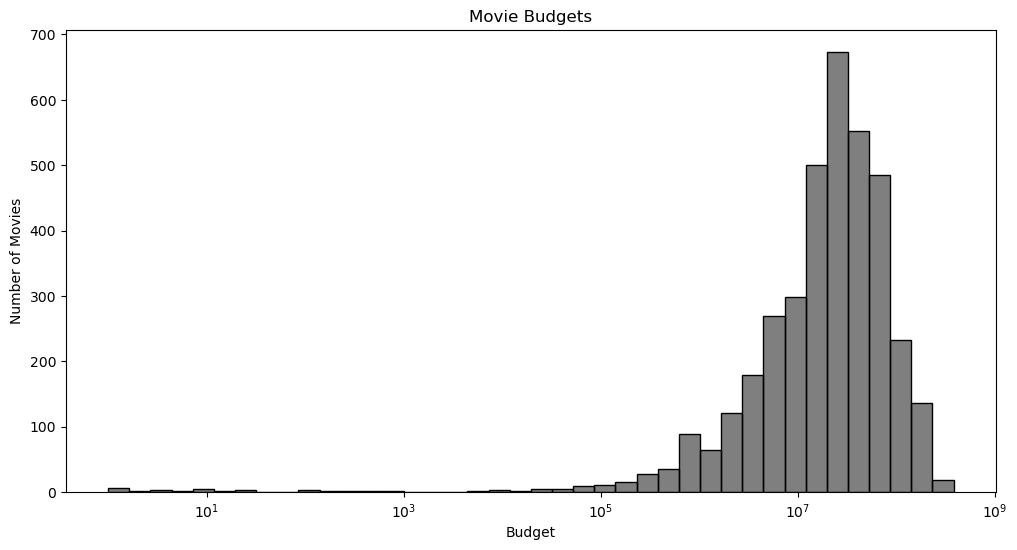

In [337]:
plt.figure(figsize=(12,6))
sns.histplot(df['budget'],bins=40,kde=True, color="black", log_scale=True)
plt.title("Movie Budgets")
plt.ylabel("Number of Movies")
plt.xlabel("Budget")
plt.show()

 Top 10 Highest-Grossing Movies

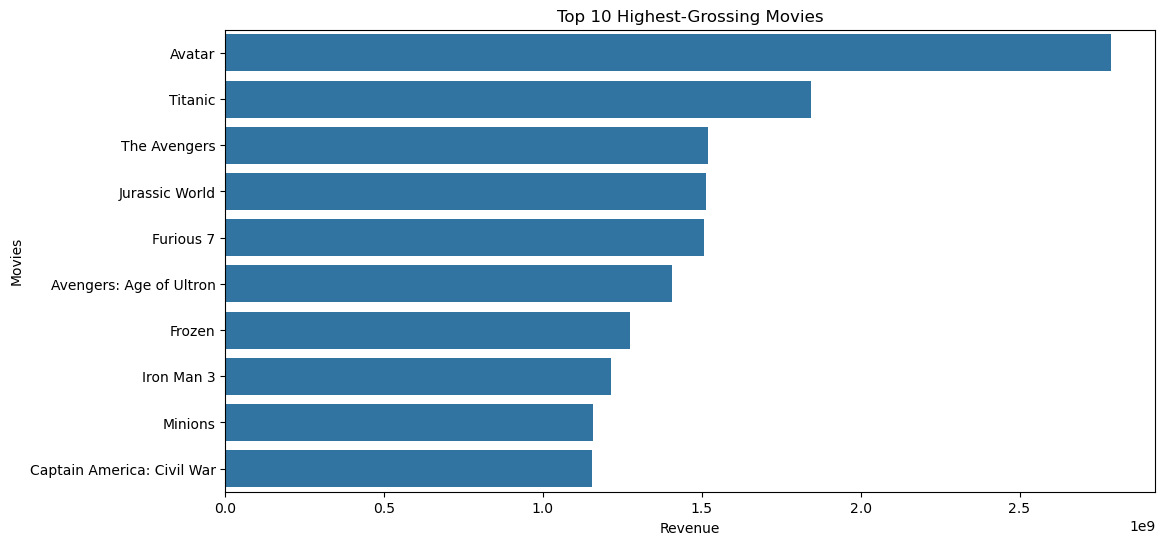

In [340]:
plt.figure(figsize=(12, 6))
top_movies = df[['title', 'revenue']].sort_values(by='revenue', ascending=False).head(10)
sns.barplot(x="revenue", y="title", data=top_movies)
plt.title("Top 10 Highest-Grossing Movies")
plt.xlabel("Revenue")
plt.ylabel("Movies")
plt.show()

Budget vs Revenue with Trendline

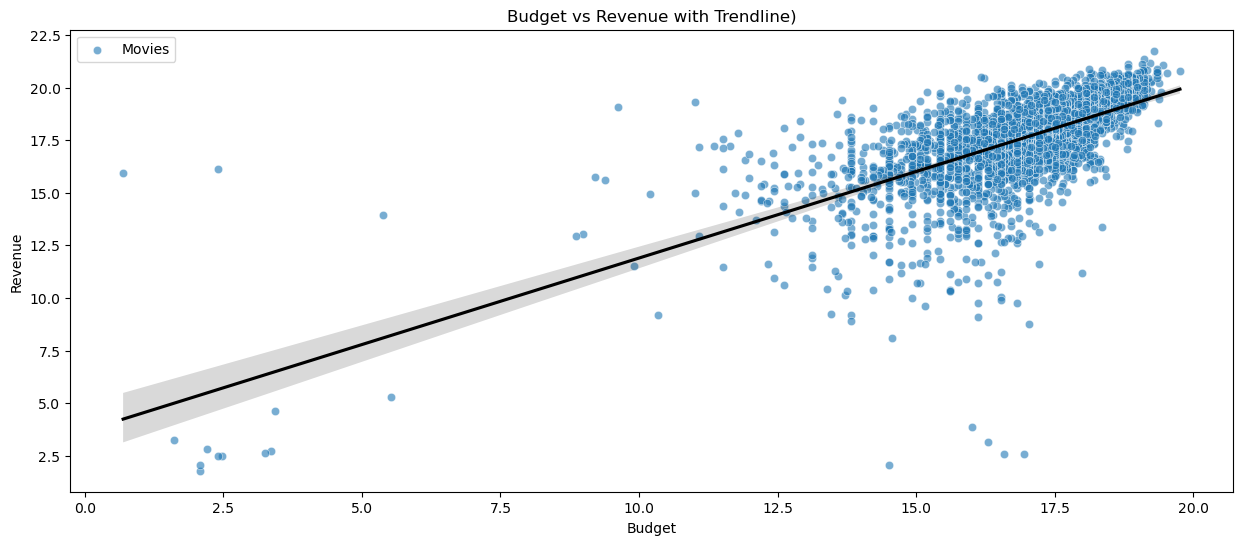

In [372]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x=df["log_budget"], y=df["log_revenue"], alpha=0.6, label="Movies")
sns.regplot(x=df["log_budget"], y=df["log_revenue"], scatter=False, color='black', line_kws={"label": "Trendline"})

plt.title("Budget vs Revenue with Trendline)")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.legend()
plt.show()

INSIGHTS:
The trendline in the Budget vs Revenue graph shows a positive correlation between budget and revenue.
However, not all high-budget movies generate high revenue, indicating that budget alone is not the key to success.
Other factors like marketing, storyline, cast, and audience demand play a significant role in a movie’s financial success.

Average Revenue by Budget Category

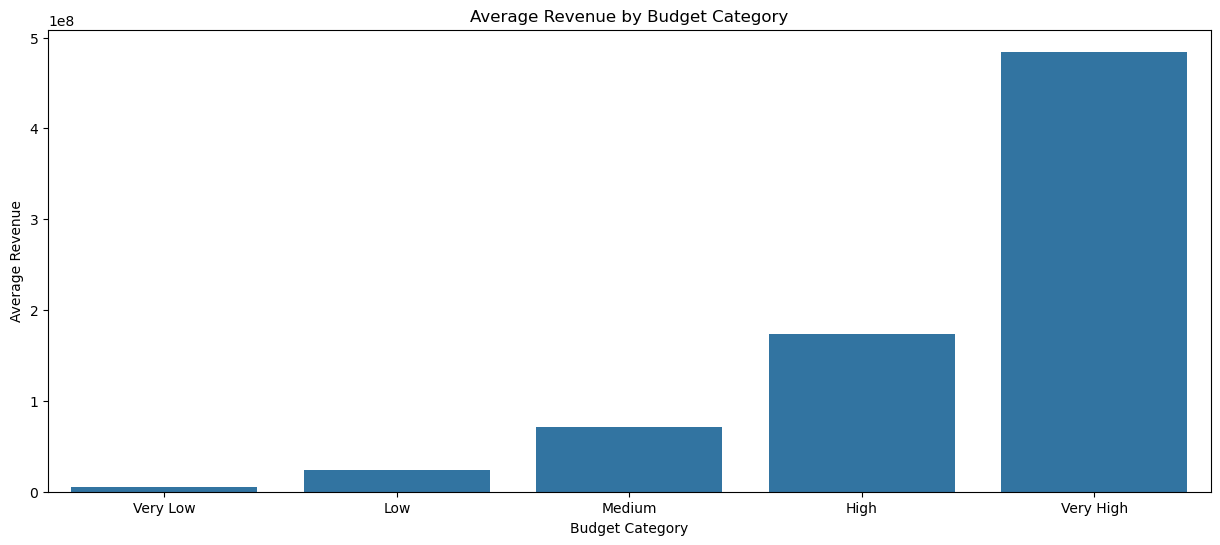

In [348]:
plt.figure(figsize=(15, 6))
bins = [0, 1_000_000, 10_000_000, 50_000_000, 100_000_000, df["budget"].max()]
labels = ["Very Low", "Low", "Medium", "High", "Very High"]
df["budget_category"] = pd.cut(df["budget"], bins=bins, labels=labels, include_lowest=True)
avg_revenue = df.groupby("budget_category", observed=False)["revenue"].mean()

sns.barplot(x=avg_revenue.index, y=avg_revenue.values)
plt.title("Average Revenue by Budget Category")
plt.xlabel("Budget Category")
plt.ylabel("Average Revenue")
plt.show()


 Number of Movies Released Each Year

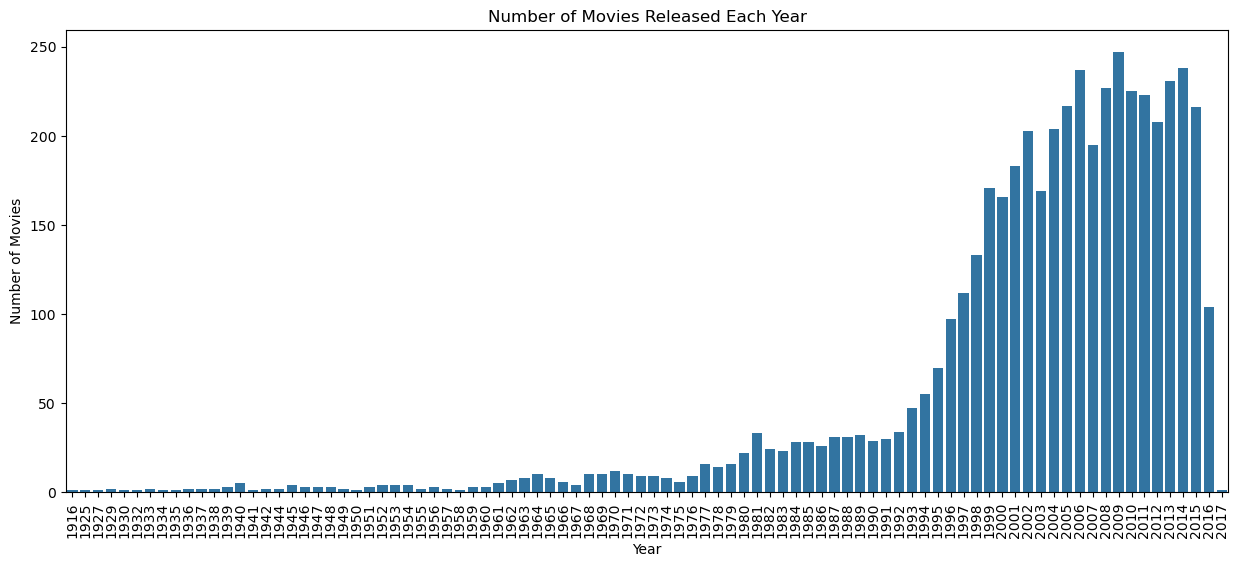

In [351]:
plt.figure(figsize=(15,6))
sns.countplot(x=df["release_year"], order=df["release_year"].value_counts().index.sort_values())
plt.xticks(rotation=90)
plt.title("Number of Movies Released Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

INSIGHTS:
The Number of Movies Released Each Year graph shows a significant increase in movie production over time, especially after 2000.
This trend is likely due to the rise of streaming platforms (Netflix, Disney+, Amazon Prime) and digital content production.
Studios should focus on creating unique and high-quality content to stay competitive in an oversaturated market.

Most Common Movie Genres

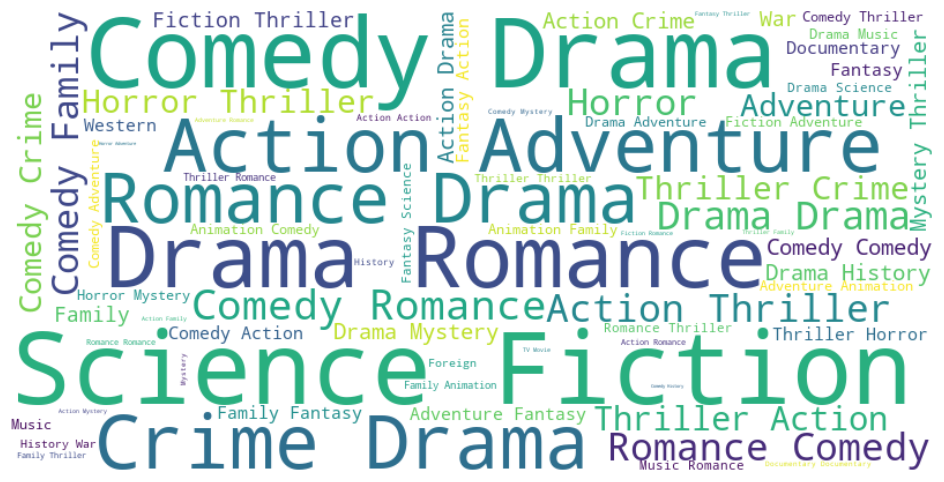

In [354]:
df["genres"] = df["genres"].apply(lambda x: [i["name"] for i in ast.literal_eval(x)] if isinstance(x, str) else [])
all_genres = [genre for sublist in df["genres"] for genre in sublist]
plt.figure(figsize=(15, 6))
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(all_genres))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

Converting WordCloud to Bar Chart 

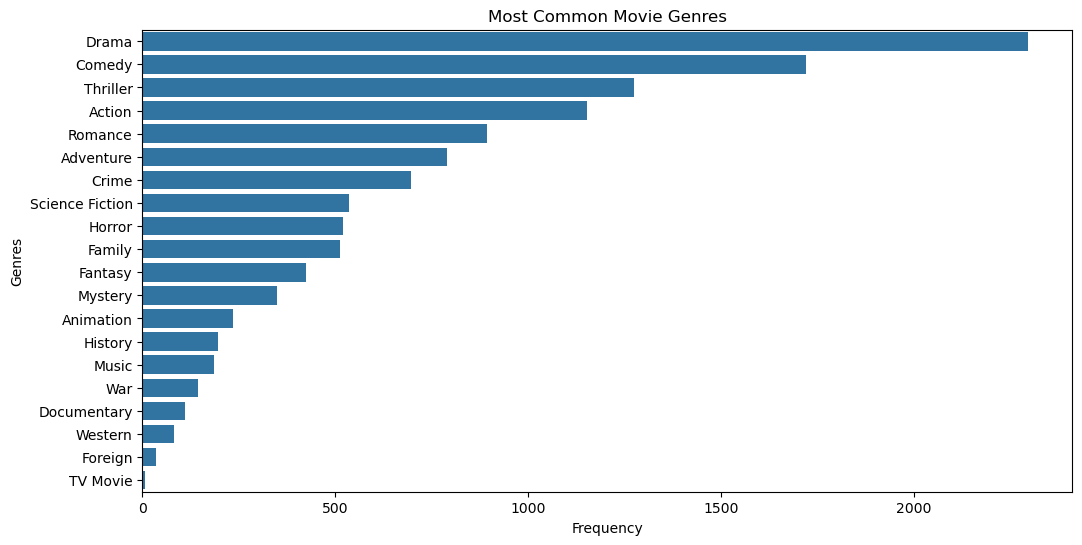

In [357]:
genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.items(), columns=["Genre", "Count"]).sort_values(by="Count", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_df["Count"], y=genre_df["Genre"])
plt.title("Most Common Movie Genres")
plt.xlabel("Frequency")
plt.ylabel("Genres")
plt.show()


INSIGHTS:
The most profitable genres include Action, Adventure, and Fantasy, as seen in the genre-based revenue analysis.
These genres perform well globally due to popular franchises (Marvel, DC, Harry Potter, etc.) and strong fan engagement.
Horror and Comedy movies typically have lower budgets but can still generate high profits, making them a low-risk investment.
Movie studios should prioritize high-budget Action and Fantasy films while also investing in profitable low-budget Horror and Comedy films.

Correlation Heatmap

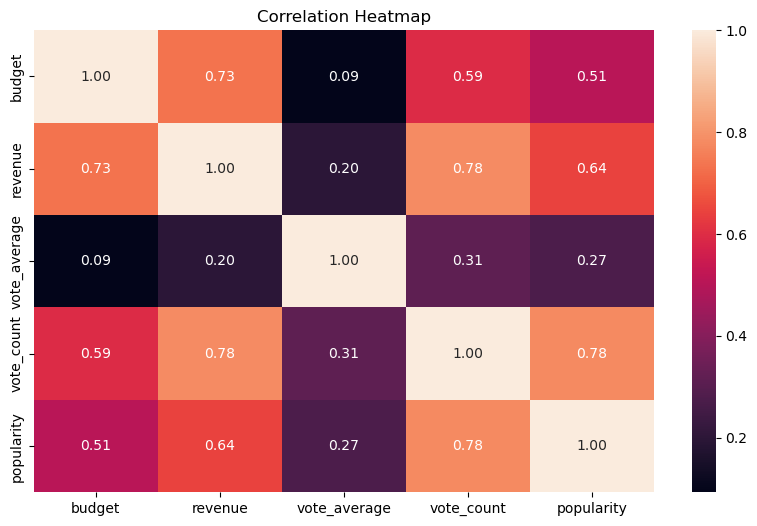

In [360]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[['budget', 'revenue', 'vote_average', 'vote_count', 'popularity']].corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

INSIGHTS:

Budget and Revenue are strongly correlated → Higher budgets usually lead to higher revenue.

Vote Count and Revenue have a positive correlation → More audience engagement boosts earnings.

Popularity and Revenue are linked → Highly marketed movies perform well financially.

Vote Average (Ratings) and Revenue have weak correlation → Good ratings don’t always mean high revenue.

Budget and Vote Average show little correlation → A high budget doesn’t guarantee audience satisfaction.